# Q-Learning: Foundational Reinforcement Learning

## 1. Introduction

In this notebook, we'll explore **Q-learning**, one of the foundational algorithms in reinforcement learning (RL). Unlike supervised learning where we learn from labeled examples, RL learns through **interaction with an environment** by trial and error.

### What We'll Build

- A complete understanding of Markov Decision Processes (MDPs)
- Q-tables that store learned value estimates
- The Q-learning algorithm from scratch
- Exploration vs exploitation strategies (ε-greedy)
- Two complete implementations: GridWorld and CartPole

### Why This Matters

Q-learning is the foundation for understanding modern deep RL algorithms like DQN, Rainbow, and beyond. It teaches us how agents can learn optimal behavior without explicit supervision - just rewards and penalties.

### Key Intuitions We'll Develop

- How agents learn from delayed rewards (credit assignment)
- The trade-off between exploring new actions vs exploiting known good ones
- How value functions capture "goodness" of states and actions
- Why temporal difference learning is more efficient than Monte Carlo methods

## 2. Setup

Let's import the necessary libraries and set up our environment.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from typing import Tuple, Dict, List
import gymnasium as gym

from aiml_notebooks import set_seed

# Configure plotting
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

Set random seed for reproducibility.

In [2]:
set_seed(42)

## 3. Reinforcement Learning Basics

### 3.1 The Agent-Environment Loop

Reinforcement learning is fundamentally about an **agent** interacting with an **environment**:

1. Agent observes current **state** $s_t$
2. Agent takes **action** $a_t$
3. Environment returns **reward** $r_{t+1}$ and next **state** $s_{t+1}$
4. Repeat

The agent's goal: learn a **policy** $\pi(a|s)$ that maximizes **cumulative reward** over time.

Unlike supervised learning where we have correct answers, the agent must discover good behavior through exploration.

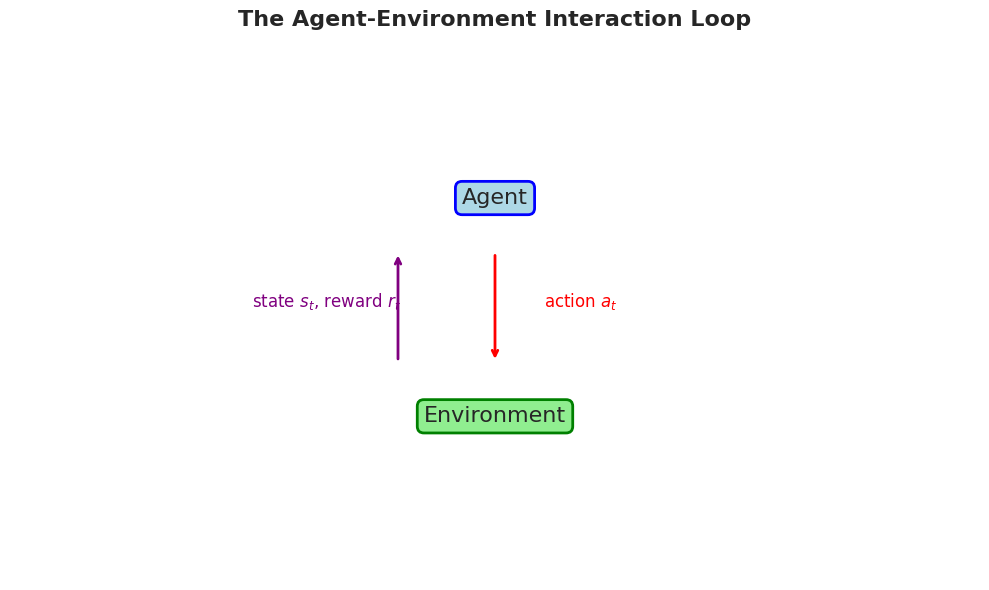

The agent learns by trying actions and observing their consequences.


In [3]:
# Visualize the RL loop
fig, ax = plt.subplots(figsize=(10, 6))
ax.text(0.5, 0.7, 'Agent', ha='center', va='center', fontsize=16, 
        bbox=dict(boxstyle='round', facecolor='lightblue', edgecolor='blue', linewidth=2))
ax.text(0.5, 0.3, 'Environment', ha='center', va='center', fontsize=16,
        bbox=dict(boxstyle='round', facecolor='lightgreen', edgecolor='green', linewidth=2))

# Action arrow
ax.annotate('', xy=(0.5, 0.4), xytext=(0.5, 0.6),
            arrowprops=dict(arrowstyle='->', lw=2, color='red'))
ax.text(0.55, 0.5, 'action $a_t$', fontsize=12, color='red')

# State and reward arrow
ax.annotate('', xy=(0.4, 0.6), xytext=(0.4, 0.4),
            arrowprops=dict(arrowstyle='->', lw=2, color='purple'))
ax.text(0.25, 0.5, 'state $s_t$, reward $r_t$', fontsize=12, color='purple')

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
ax.set_title('The Agent-Environment Interaction Loop', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("The agent learns by trying actions and observing their consequences.")

### 3.2 Key Definitions

- **State** $s$: The current situation the agent finds itself in
- **Action** $a$: A choice the agent can make
- **Reward** $r$: Immediate feedback (positive or negative) from the environment
- **Policy** $\pi(a|s)$: The agent's strategy - which action to take in each state
- **Episode**: A complete sequence from start state to terminal state

The challenge: rewards can be **delayed**. An action taken now might only show its benefit (or harm) many steps later.

## 4. Markov Decision Processes (MDPs)

### 4.1 What is an MDP?

A **Markov Decision Process** is the mathematical framework for RL. It consists of:

- $\mathcal{S}$: Set of states
- $\mathcal{A}$: Set of actions
- $P(s'|s,a)$: Transition probability (dynamics)
- $R(s,a,s')$: Reward function
- $\gamma$: Discount factor (0 ≤ γ < 1)

The **Markov property**: The future depends only on the current state, not the history.

$$P(s_{t+1} | s_t, a_t, s_{t-1}, a_{t-1}, ...) = P(s_{t+1} | s_t, a_t)$$

This means the current state contains all relevant information for decision-making.

### 4.2 Return and Discounting

The **return** $G_t$ is the total discounted reward from time $t$ onwards:

$$G_t = r_{t+1} + \gamma r_{t+2} + \gamma^2 r_{t+3} + ... = \sum_{k=0}^{\infty} \gamma^k r_{t+k+1}$$

Why discount ($\gamma < 1$)?
- **Mathematical convenience**: Infinite sums converge
- **Uncertainty**: Future rewards are less certain
- **Preference for immediate reward**: Getting $10 now is better than $10 later

When $\gamma = 0$: Agent is myopic (only cares about immediate reward)
When $\gamma \to 1$: Agent is far-sighted (values future almost as much as present)

In [4]:
# Visualize discounting effect
def calculate_return(rewards, gamma):
    """Calculate discounted return from a sequence of rewards."""
    return sum(gamma**i * r for i, r in enumerate(rewards))

# Example: sequence of rewards [1, 1, 1, 1, 1]
rewards = [1, 1, 1, 1, 1]
gammas = [0.0, 0.5, 0.9, 0.99]

for gamma in gammas:
    G = calculate_return(rewards, gamma)
    print(f"γ = {gamma:.2f}: Return = {G:.3f}")

print("\nLower γ makes the agent more short-sighted (myopic).")
print("Higher γ makes the agent more far-sighted (patient).")

γ = 0.00: Return = 1.000
γ = 0.50: Return = 1.938
γ = 0.90: Return = 4.095
γ = 0.99: Return = 4.901

Lower γ makes the agent more short-sighted (myopic).
Higher γ makes the agent more far-sighted (patient).


Execute the following code:

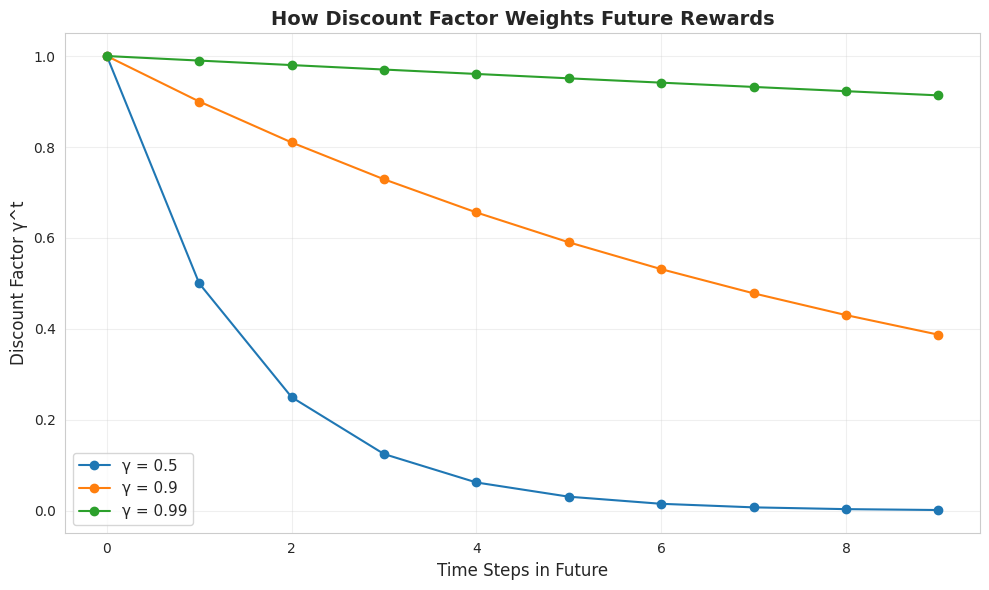

Notice how rewards far in the future get exponentially less weight.


In [5]:
# Visualize discount factors over time
time_steps = np.arange(10)
gammas = [0.5, 0.9, 0.99]

plt.figure(figsize=(10, 6))
for gamma in gammas:
    discount_factors = gamma ** time_steps
    plt.plot(time_steps, discount_factors, marker='o', label=f'γ = {gamma}')

plt.xlabel('Time Steps in Future', fontsize=12)
plt.ylabel('Discount Factor γ^t', fontsize=12)
plt.title('How Discount Factor Weights Future Rewards', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Notice how rewards far in the future get exponentially less weight.")

### 4.3 Value Functions

Value functions tell us how "good" states or state-action pairs are.

**State-value function** $V^\pi(s)$: Expected return starting from state $s$ and following policy $\pi$

$$V^\pi(s) = \mathbb{E}_\pi[G_t | s_t = s]$$

**Action-value function** $Q^\pi(s,a)$: Expected return starting from state $s$, taking action $a$, then following policy $\pi$

$$Q^\pi(s,a) = \mathbb{E}_\pi[G_t | s_t = s, a_t = a]$$

The **Q-function** is what we'll learn with Q-learning!

### 4.4 Optimal Value Functions

The **optimal** value functions represent the best possible expected return:

$$V^*(s) = \max_\pi V^\pi(s)$$
$$Q^*(s,a) = \max_\pi Q^\pi(s,a)$$

Once we know $Q^*(s,a)$, the optimal policy is simple:

$$\pi^*(s) = \arg\max_a Q^*(s,a)$$

Just pick the action with highest Q-value! This is why learning Q is so powerful.

## 5. GridWorld Environment

### 5.1 Defining GridWorld

Let's build a simple GridWorld to understand Q-learning. It's a 4×4 grid where:
- Agent starts at position (0,0)
- Goal is at position (3,3) with reward +1
- All other moves give reward -0.01 (small penalty to encourage efficiency)
- Agent can move up, down, left, right
- Walls block movement (agent stays in place)

This is a perfect testbed: simple enough to understand, complex enough to be interesting.

In [6]:
class GridWorld:
    """Simple grid world environment for Q-learning."""
    
    def __init__(self, size: int = 4):
        self.size = size
        self.n_states = size * size
        self.n_actions = 4  # up, down, left, right
        
        # Action mapping
        self.actions = {
            0: (-1, 0),  # up
            1: (1, 0),   # down
            2: (0, -1),  # left
            3: (0, 1)    # right
        }
        self.action_names = ['↑', '↓', '←', '→']
        
        # Start and goal positions
        self.start_pos = (0, 0)
        self.goal_pos = (size - 1, size - 1)
        
        self.reset()
    
    def reset(self) -> Tuple[int, int]:
        """Reset environment to start state."""
        self.agent_pos = self.start_pos
        return self.agent_pos
    
    def step(self, action: int) -> Tuple[Tuple[int, int], float, bool]:
        """Take action and return (next_state, reward, done)."""
        # Get action direction
        dy, dx = self.actions[action]
        
        # Calculate new position
        new_y = self.agent_pos[0] + dy
        new_x = self.agent_pos[1] + dx
        
        # Check boundaries (walls)
        if 0 <= new_y < self.size and 0 <= new_x < self.size:
            self.agent_pos = (new_y, new_x)
        
        # Calculate reward
        if self.agent_pos == self.goal_pos:
            reward = 1.0
            done = True
        else:
            reward = -0.01  # Small penalty to encourage efficiency
            done = False
        
        return self.agent_pos, reward, done
    
    def render(self, q_table: Dict = None):
        """Visualize the grid world and optionally the Q-values."""
        grid = np.zeros((self.size, self.size))
        grid[self.goal_pos] = 2  # Goal
        grid[self.agent_pos] = 1  # Agent
        
        fig, ax = plt.subplots(figsize=(8, 8))
        ax.imshow(grid, cmap='RdYlGn', alpha=0.6)
        
        # Draw grid lines
        for i in range(self.size + 1):
            ax.axhline(i - 0.5, color='black', linewidth=1)
            ax.axvline(i - 0.5, color='black', linewidth=1)
        
        # Draw policy arrows if Q-table provided
        if q_table is not None:
            for y in range(self.size):
                for x in range(self.size):
                    state = (y, x)
                    if state == self.goal_pos:
                        continue
                    
                    # Get best action
                    q_values = [q_table.get((state, a), 0) for a in range(self.n_actions)]
                    best_action = np.argmax(q_values)
                    
                    # Draw arrow
                    arrow = self.action_names[best_action]
                    ax.text(x, y, arrow, ha='center', va='center', 
                           fontsize=20, fontweight='bold')
        
        # Labels
        ax.text(self.start_pos[1], self.start_pos[0] - 0.3, 'START', 
               ha='center', fontsize=10, fontweight='bold', color='blue')
        ax.text(self.goal_pos[1], self.goal_pos[0] + 0.3, 'GOAL', 
               ha='center', fontsize=10, fontweight='bold', color='green')
        
        ax.set_xlim(-0.5, self.size - 0.5)
        ax.set_ylim(self.size - 0.5, -0.5)
        ax.set_xticks(range(self.size))
        ax.set_yticks(range(self.size))
        ax.set_title('GridWorld Environment', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

Let's create and visualize our GridWorld.

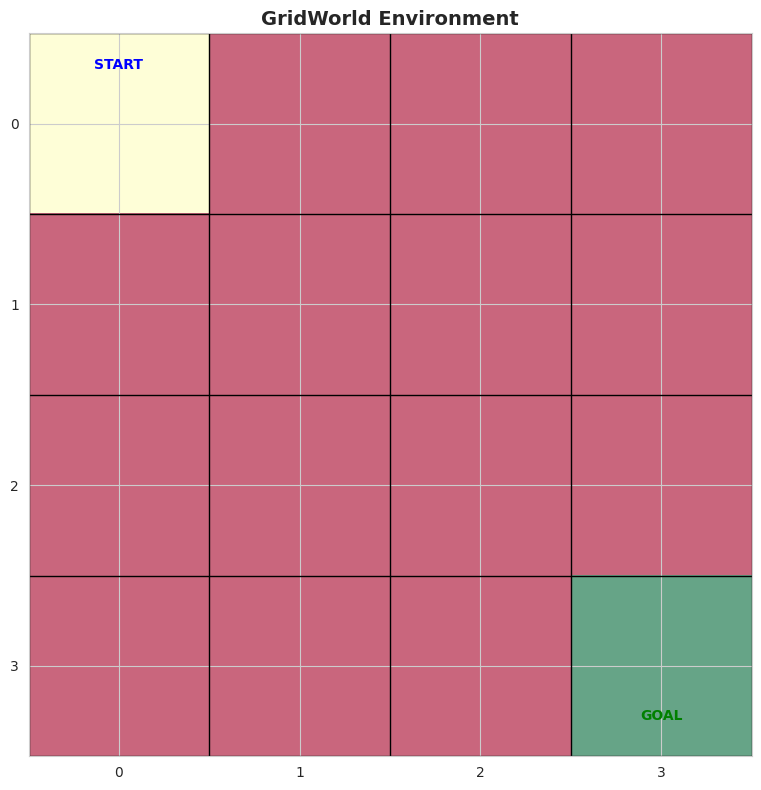

State space size: 16
Action space size: 4
Actions: ['↑', '↓', '←', '→']


In [7]:
env = GridWorld(size=4)
env.render()

print(f"State space size: {env.n_states}")
print(f"Action space size: {env.n_actions}")
print(f"Actions: {env.action_names}")

### 5.2 Testing the Environment

Let's manually interact with the environment to understand its dynamics.

In [8]:
# Test the environment
env = GridWorld(size=4)
state = env.reset()
print(f"Initial state: {state}")

# Try moving right twice and down twice (should reach goal)
actions = [3, 3, 3, 1, 1, 1]  # right, right, right, down, down, down
total_reward = 0

for i, action in enumerate(actions):
    state, reward, done = env.step(action)
    total_reward += reward
    print(f"Step {i+1}: Action={env.action_names[action]}, State={state}, Reward={reward:.2f}, Done={done}")
    
    if done:
        break

print(f"\nTotal reward: {total_reward:.2f}")
print(f"Number of steps: {i+1}")

Initial state: (0, 0)
Step 1: Action=→, State=(0, 1), Reward=-0.01, Done=False
Step 2: Action=→, State=(0, 2), Reward=-0.01, Done=False
Step 3: Action=→, State=(0, 3), Reward=-0.01, Done=False
Step 4: Action=↓, State=(1, 3), Reward=-0.01, Done=False
Step 5: Action=↓, State=(2, 3), Reward=-0.01, Done=False
Step 6: Action=↓, State=(3, 3), Reward=1.00, Done=True

Total reward: 0.95
Number of steps: 6


## 6. Q-Tables and Q-Values

### 6.1 What is a Q-Table?

A **Q-table** is a lookup table that stores Q-values for every (state, action) pair:

| State | ↑ | ↓ | ← | → |
|-------|-----|-----|-----|-----|
| (0,0) | 0.1 | 0.3 | 0.0 | **0.5** |
| (0,1) | 0.2 | 0.4 | 0.1 | **0.6** |
| ... | ... | ... | ... | ... |

Each entry $Q(s,a)$ estimates: "If I'm in state $s$ and take action $a$, what total reward will I get?"

**Key insight**: The action with the highest Q-value in each state is the best action to take!

In [9]:
# Initialize Q-table as a dictionary
# Dictionary is better than array when state space is large or continuous
q_table = defaultdict(lambda: 0.0)

# Example: set some Q-values manually
state = (0, 0)
q_table[(state, 0)] = 0.1  # up
q_table[(state, 1)] = 0.3  # down
q_table[(state, 2)] = 0.0  # left
q_table[(state, 3)] = 0.5  # right (highest!)

# Get Q-values for this state
q_values = [q_table[(state, a)] for a in range(4)]
best_action = np.argmax(q_values)

print(f"Q-values for state {state}:")
for a, name in enumerate(env.action_names):
    print(f"  {name}: {q_values[a]:.2f}")
print(f"\nBest action: {env.action_names[best_action]} (Q = {q_values[best_action]:.2f})")

Q-values for state (0, 0):
  ↑: 0.10
  ↓: 0.30
  ←: 0.00
  →: 0.50

Best action: → (Q = 0.50)


### 6.2 The Bellman Equation

The **Bellman equation** relates Q-values recursively:

$$Q^*(s,a) = \mathbb{E}[r + \gamma \max_{a'} Q^*(s', a')]$$

In words: "The value of taking action $a$ in state $s$ equals the immediate reward $r$ plus the discounted value of the best action in the next state $s'$."

This is the foundation of Q-learning! We'll use this equation to update our Q-values.

## 7. The Q-Learning Algorithm

### 7.1 The Update Rule

Q-learning learns Q-values through **temporal difference (TD) learning**:

$$Q(s,a) \leftarrow Q(s,a) + \alpha [r + \gamma \max_{a'} Q(s', a') - Q(s,a)]$$

Breaking this down:
- $\alpha$: **learning rate** (how much to update)
- $r + \gamma \max_{a'} Q(s', a')$: **TD target** (what we think Q should be)
- $r + \gamma \max_{a'} Q(s', a') - Q(s,a)$: **TD error** (how wrong we were)

We move Q-values toward the TD target, scaled by the learning rate.

In [10]:
# Demonstrate a single Q-learning update
def q_learning_update(q_table: Dict, state: tuple, action: int, reward: float, 
                      next_state: tuple, n_actions: int, alpha: float = 0.1, 
                      gamma: float = 0.99) -> float:
    """Perform one Q-learning update and return TD error."""
    # Current Q-value
    current_q = q_table[(state, action)]
    
    # Maximum Q-value for next state
    max_next_q = max([q_table[(next_state, a)] for a in range(n_actions)])
    
    # TD target and error
    td_target = reward + gamma * max_next_q
    td_error = td_target - current_q
    
    # Update Q-value
    q_table[(state, action)] = current_q + alpha * td_error
    
    return td_error

# Example update
test_q_table = defaultdict(lambda: 0.0)
test_q_table[((0, 0), 3)] = 0.5  # right action from (0,0)
test_q_table[((0, 1), 3)] = 0.6  # best action from next state

state = (0, 0)
action = 3  # right
reward = -0.01
next_state = (0, 1)

print("Before update:")
print(f"  Q({state}, right) = {test_q_table[(state, action)]:.4f}")

td_error = q_learning_update(test_q_table, state, action, reward, next_state, 4)

print("\nAfter update:")
print(f"  Q({state}, right) = {test_q_table[(state, action)]:.4f}")
print(f"  TD error = {td_error:.4f}")
print(f"\nThe Q-value increased because the next state has higher value!")

Before update:
  Q((0, 0), right) = 0.5000

After update:
  Q((0, 0), right) = 0.5084
  TD error = 0.0840

The Q-value increased because the next state has higher value!


### 7.2 Why Q-Learning Works

Q-learning is **off-policy**: it learns the optimal policy while following a different (exploratory) policy.

Key properties:
1. **Bootstrapping**: Uses estimate of next state to update current state
2. **Temporal Difference**: Updates after each step (not waiting for episode end)
3. **Model-free**: Doesn't need to know environment dynamics $P(s'|s,a)$
4. **Convergence guarantee**: Will converge to $Q^*$ if all state-action pairs are visited infinitely often

The last point is crucial - we need exploration!

## 8. Exploration vs Exploitation

### 8.1 The Exploration-Exploitation Dilemma

**The Problem**: Should the agent:
- **Exploit**: Choose the action with highest known Q-value (greedy)
- **Explore**: Try other actions to discover if they're better

If we only exploit, we might miss better strategies. If we only explore, we never use what we learned.

This is a fundamental trade-off in RL!

### 8.2 ε-Greedy Strategy

The **ε-greedy** policy balances exploration and exploitation:

- With probability $\epsilon$: choose **random action** (explore)
- With probability $1-\epsilon$: choose **best action** (exploit)

Typically, we start with high $\epsilon$ (explore more early) and decay it over time (exploit more later).

$$\epsilon_t = \epsilon_{\text{min}} + (\epsilon_{\text{max}} - \epsilon_{\text{min}}) \cdot e^{-\text{decay} \cdot t}$$

In [11]:
def epsilon_greedy_policy(q_table: Dict, state: tuple, n_actions: int, epsilon: float) -> int:
    """Select action using epsilon-greedy strategy."""
    if np.random.random() < epsilon:
        # Explore: random action
        return np.random.randint(n_actions)
    else:
        # Exploit: best action
        q_values = [q_table[(state, a)] for a in range(n_actions)]
        return np.argmax(q_values)

# Test epsilon-greedy with different epsilon values
test_q_table = defaultdict(lambda: 0.0)
state = (1, 1)
test_q_table[(state, 0)] = 0.1
test_q_table[(state, 1)] = 0.3
test_q_table[(state, 2)] = 0.2
test_q_table[(state, 3)] = 0.8  # Best action!

print("Action selection with different epsilon values:\n")
for epsilon in [0.0, 0.1, 0.5, 1.0]:
    actions = [epsilon_greedy_policy(test_q_table, state, 4, epsilon) for _ in range(1000)]
    action_counts = np.bincount(actions, minlength=4)
    print(f"ε = {epsilon:.1f}:")
    for a, count in enumerate(action_counts):
        print(f"  Action {a} ({env.action_names[a]}): {count/10:.1f}%")
    print()

Action selection with different epsilon values:

ε = 0.0:
  Action 0 (↑): 0.0%
  Action 1 (↓): 0.0%
  Action 2 (←): 0.0%
  Action 3 (→): 100.0%

ε = 0.1:
  Action 0 (↑): 2.5%
  Action 1 (↓): 3.1%
  Action 2 (←): 2.2%
  Action 3 (→): 92.2%

ε = 0.5:
  Action 0 (↑): 12.4%
  Action 1 (↓): 11.1%
  Action 2 (←): 11.7%
  Action 3 (→): 64.8%

ε = 1.0:
  Action 0 (↑): 24.0%
  Action 1 (↓): 25.0%
  Action 2 (←): 26.1%
  Action 3 (→): 24.9%



Execute the following code:

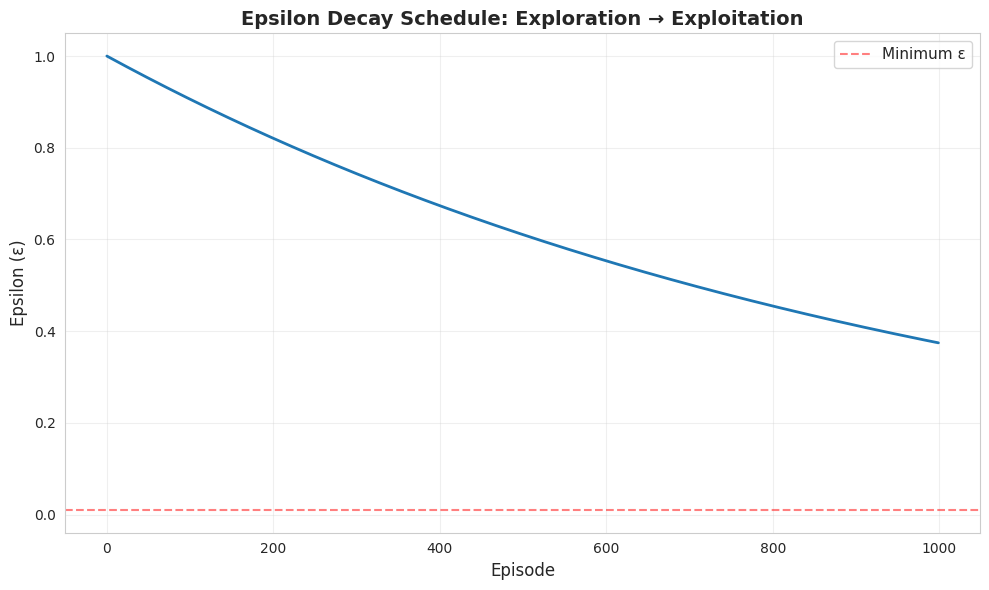

Early episodes: High ε → more exploration (learn about environment)
Later episodes: Low ε → more exploitation (use what we learned)


In [12]:
# Visualize epsilon decay
def epsilon_decay(episode: int, epsilon_start: float = 1.0, epsilon_end: float = 0.01, 
                  epsilon_decay_rate: float = 0.001) -> float:
    """Calculate epsilon for given episode with exponential decay."""
    return epsilon_end + (epsilon_start - epsilon_end) * np.exp(-epsilon_decay_rate * episode)

episodes = np.arange(1000)
epsilons = [epsilon_decay(ep) for ep in episodes]

plt.figure(figsize=(10, 6))
plt.plot(episodes, epsilons, linewidth=2)
plt.xlabel('Episode', fontsize=12)
plt.ylabel('Epsilon (ε)', fontsize=12)
plt.title('Epsilon Decay Schedule: Exploration → Exploitation', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axhline(0.01, color='red', linestyle='--', alpha=0.5, label='Minimum ε')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("Early episodes: High ε → more exploration (learn about environment)")
print("Later episodes: Low ε → more exploitation (use what we learned)")

## 9. Complete Q-Learning Implementation

### 9.1 The Full Algorithm

Now let's put everything together into a complete Q-learning agent.

In [13]:
class QLearningAgent:
    """Q-Learning agent for discrete state and action spaces."""
    
    def __init__(self, n_actions: int, learning_rate: float = 0.1, 
                 discount_factor: float = 0.99, epsilon_start: float = 1.0,
                 epsilon_end: float = 0.01, epsilon_decay: float = 0.001):
        self.n_actions = n_actions
        self.lr = learning_rate
        self.gamma = discount_factor
        self.epsilon_start = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.episode = 0
        
        # Q-table
        self.q_table = defaultdict(lambda: 0.0)
    
    def get_epsilon(self) -> float:
        """Calculate current epsilon value."""
        return self.epsilon_end + (self.epsilon_start - self.epsilon_end) * \
               np.exp(-self.epsilon_decay * self.episode)
    
    def select_action(self, state: tuple, training: bool = True) -> int:
        """Select action using epsilon-greedy policy."""
        epsilon = self.get_epsilon() if training else 0.0
        
        if np.random.random() < epsilon:
            return np.random.randint(self.n_actions)
        else:
            q_values = [self.q_table[(state, a)] for a in range(self.n_actions)]
            return np.argmax(q_values)
    
    def update(self, state: tuple, action: int, reward: float, 
               next_state: tuple, done: bool) -> float:
        """Update Q-value using Q-learning rule."""
        current_q = self.q_table[(state, action)]
        
        if done:
            # No future rewards if episode ended
            td_target = reward
        else:
            max_next_q = max([self.q_table[(next_state, a)] for a in range(self.n_actions)])
            td_target = reward + self.gamma * max_next_q
        
        td_error = td_target - current_q
        self.q_table[(state, action)] = current_q + self.lr * td_error
        
        return td_error
    
    def train_episode(self, env) -> Tuple[float, int]:
        """Train for one episode. Returns (total_reward, steps)."""
        state = env.reset()
        total_reward = 0
        steps = 0
        
        while True:
            action = self.select_action(state, training=True)
            next_state, reward, done = env.step(action)
            
            self.update(state, action, reward, next_state, done)
            
            state = next_state
            total_reward += reward
            steps += 1
            
            if done or steps > 100:  # Timeout after 100 steps
                break
        
        self.episode += 1
        return total_reward, steps

print("Q-Learning agent ready!")
print("\nHyperparameters:")
print("  - Learning rate (α): Controls update size")
print("  - Discount factor (γ): Values future rewards")
print("  - Epsilon (ε): Controls exploration vs exploitation")

Q-Learning agent ready!

Hyperparameters:
  - Learning rate (α): Controls update size
  - Discount factor (γ): Values future rewards
  - Epsilon (ε): Controls exploration vs exploitation


### 9.2 Training on GridWorld

Let's train our agent and watch it learn!

In [14]:
# Create environment and agent
env = GridWorld(size=4)
agent = QLearningAgent(
    n_actions=env.n_actions,
    learning_rate=0.1,
    discount_factor=0.99,
    epsilon_start=1.0,
    epsilon_end=0.01,
    epsilon_decay=0.005
)

# Training loop
n_episodes = 500
rewards_history = []
steps_history = []

for episode in range(n_episodes):
    total_reward, steps = agent.train_episode(env)
    rewards_history.append(total_reward)
    steps_history.append(steps)
    
    if (episode + 1) % 100 == 0:
        avg_reward = np.mean(rewards_history[-100:])
        avg_steps = np.mean(steps_history[-100:])
        epsilon = agent.get_epsilon()
        print(f"Episode {episode + 1}: Avg Reward = {avg_reward:.3f}, Avg Steps = {avg_steps:.1f}, ε = {epsilon:.3f}")

print("\nTraining complete!")

Episode 100: Avg Reward = 0.698, Avg Steps = 27.2, ε = 0.610
Episode 200: Avg Reward = 0.903, Avg Steps = 10.7, ε = 0.374
Episode 300: Avg Reward = 0.929, Avg Steps = 8.1, ε = 0.231
Episode 400: Avg Reward = 0.936, Avg Steps = 7.4, ε = 0.144
Episode 500: Avg Reward = 0.943, Avg Steps = 6.7, ε = 0.091

Training complete!


### 9.3 Visualizing Learning Progress

Let's plot how the agent improved over time.

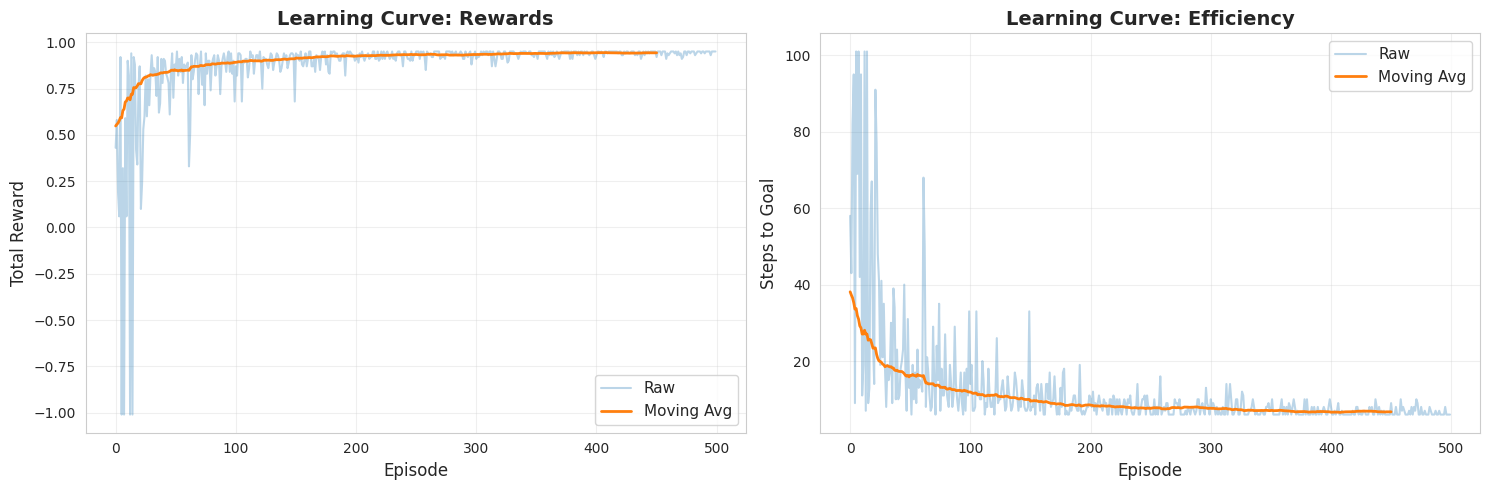

Key observations:
  - Rewards increase as agent learns optimal policy
  - Steps decrease as agent finds shorter paths
  - Variance decreases as exploration (ε) decays


In [15]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Moving average for smoothing
def moving_average(data, window=50):
    return np.convolve(data, np.ones(window)/window, mode='valid')

# Rewards
axes[0].plot(rewards_history, alpha=0.3, label='Raw')
axes[0].plot(moving_average(rewards_history), linewidth=2, label='Moving Avg')
axes[0].set_xlabel('Episode', fontsize=12)
axes[0].set_ylabel('Total Reward', fontsize=12)
axes[0].set_title('Learning Curve: Rewards', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Steps
axes[1].plot(steps_history, alpha=0.3, label='Raw')
axes[1].plot(moving_average(steps_history), linewidth=2, label='Moving Avg')
axes[1].set_xlabel('Episode', fontsize=12)
axes[1].set_ylabel('Steps to Goal', fontsize=12)
axes[1].set_title('Learning Curve: Efficiency', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Key observations:")
print("  - Rewards increase as agent learns optimal policy")
print("  - Steps decrease as agent finds shorter paths")
print("  - Variance decreases as exploration (ε) decays")

### 9.4 Visualizing the Learned Policy

Let's see what policy the agent learned!

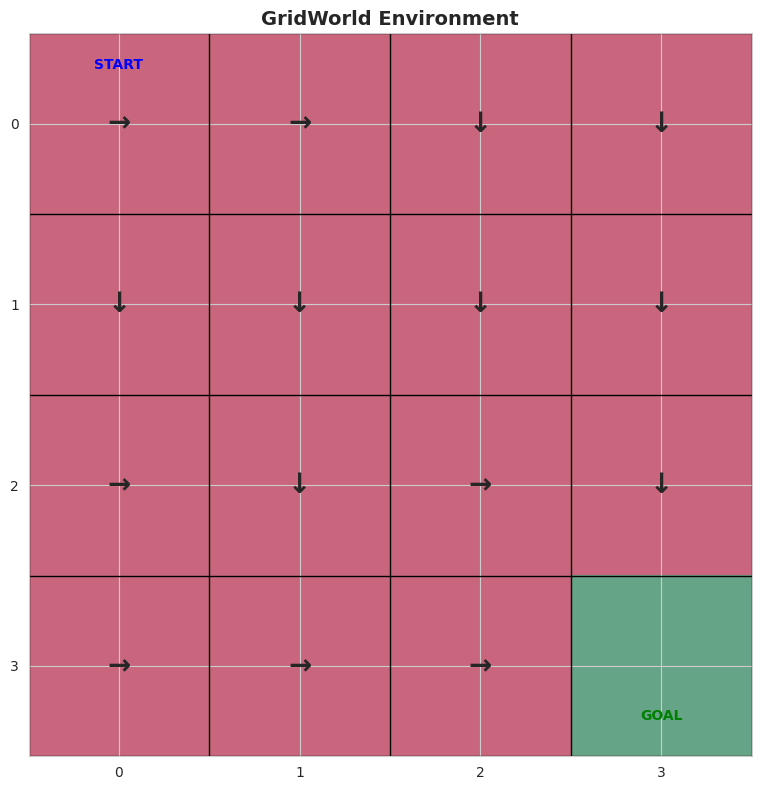

Arrows show the best action (highest Q-value) in each state.
The agent learned to navigate optimally to the goal!


In [16]:
# Visualize learned policy
env.render(q_table=agent.q_table)

print("Arrows show the best action (highest Q-value) in each state.")
print("The agent learned to navigate optimally to the goal!")

### 9.5 Testing the Learned Policy

Let's watch the trained agent navigate the grid without exploration.

In [17]:
# Test learned policy
env = GridWorld(size=4)
state = env.reset()
path = [state]
total_reward = 0

print("Testing learned policy (greedy, no exploration):\n")
print(f"Start: {state}")

for step in range(20):
    action = agent.select_action(state, training=False)  # Greedy
    next_state, reward, done = env.step(action)
    path.append(next_state)
    total_reward += reward
    
    print(f"  Step {step + 1}: {state} --[{env.action_names[action]}]--> {next_state} (reward: {reward:.2f})")
    
    state = next_state
    
    if done:
        print(f"\nGoal reached in {step + 1} steps!")
        print(f"Total reward: {total_reward:.2f}")
        break

print(f"\nOptimal path: {' → '.join(map(str, path))}")

Testing learned policy (greedy, no exploration):

Start: (0, 0)
  Step 1: (0, 0) --[→]--> (0, 1) (reward: -0.01)
  Step 2: (0, 1) --[→]--> (0, 2) (reward: -0.01)
  Step 3: (0, 2) --[↓]--> (1, 2) (reward: -0.01)
  Step 4: (1, 2) --[↓]--> (2, 2) (reward: -0.01)
  Step 5: (2, 2) --[→]--> (2, 3) (reward: -0.01)
  Step 6: (2, 3) --[↓]--> (3, 3) (reward: 1.00)

Goal reached in 6 steps!
Total reward: 0.95

Optimal path: (0, 0) → (0, 1) → (0, 2) → (1, 2) → (2, 2) → (2, 3) → (3, 3)


## 10. Visualizing Q-Values

### 10.1 Q-Value Heatmap

Let's visualize the Q-values for each state to understand what the agent learned.

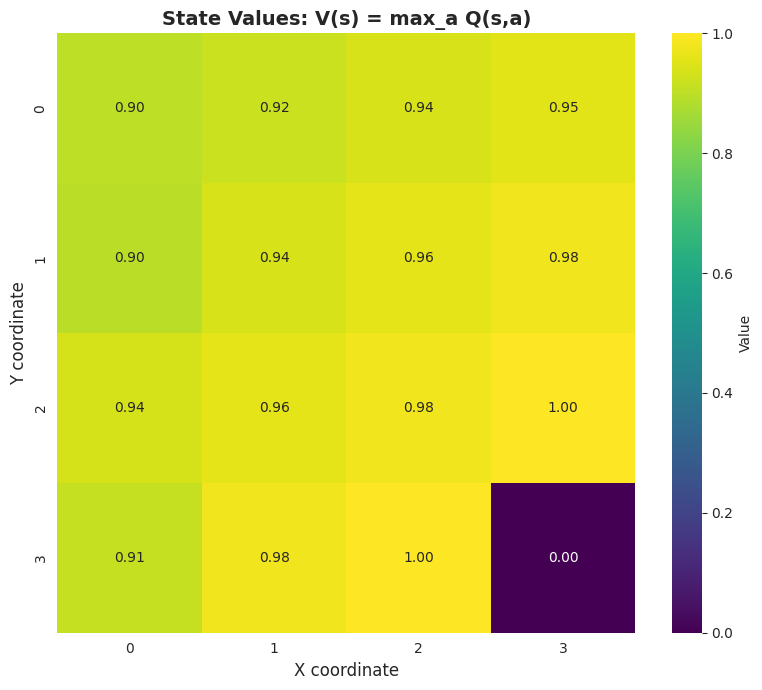

Higher values (lighter colors) indicate states closer to the goal.
The value gradient points toward the optimal path!


In [18]:
# Create heatmap of maximum Q-values (V-values) for each state
v_values = np.zeros((env.size, env.size))

for y in range(env.size):
    for x in range(env.size):
        state = (y, x)
        q_values = [agent.q_table[(state, a)] for a in range(env.n_actions)]
        v_values[y, x] = max(q_values)

plt.figure(figsize=(8, 7))
sns.heatmap(v_values, annot=True, fmt='.2f', cmap='viridis', cbar_kws={'label': 'Value'})
plt.title('State Values: V(s) = max_a Q(s,a)', fontsize=14, fontweight='bold')
plt.xlabel('X coordinate', fontsize=12)
plt.ylabel('Y coordinate', fontsize=12)
plt.tight_layout()
plt.show()

print("Higher values (lighter colors) indicate states closer to the goal.")
print("The value gradient points toward the optimal path!")

### 10.2 Q-Values for All Actions

Let's visualize Q-values for each action separately.

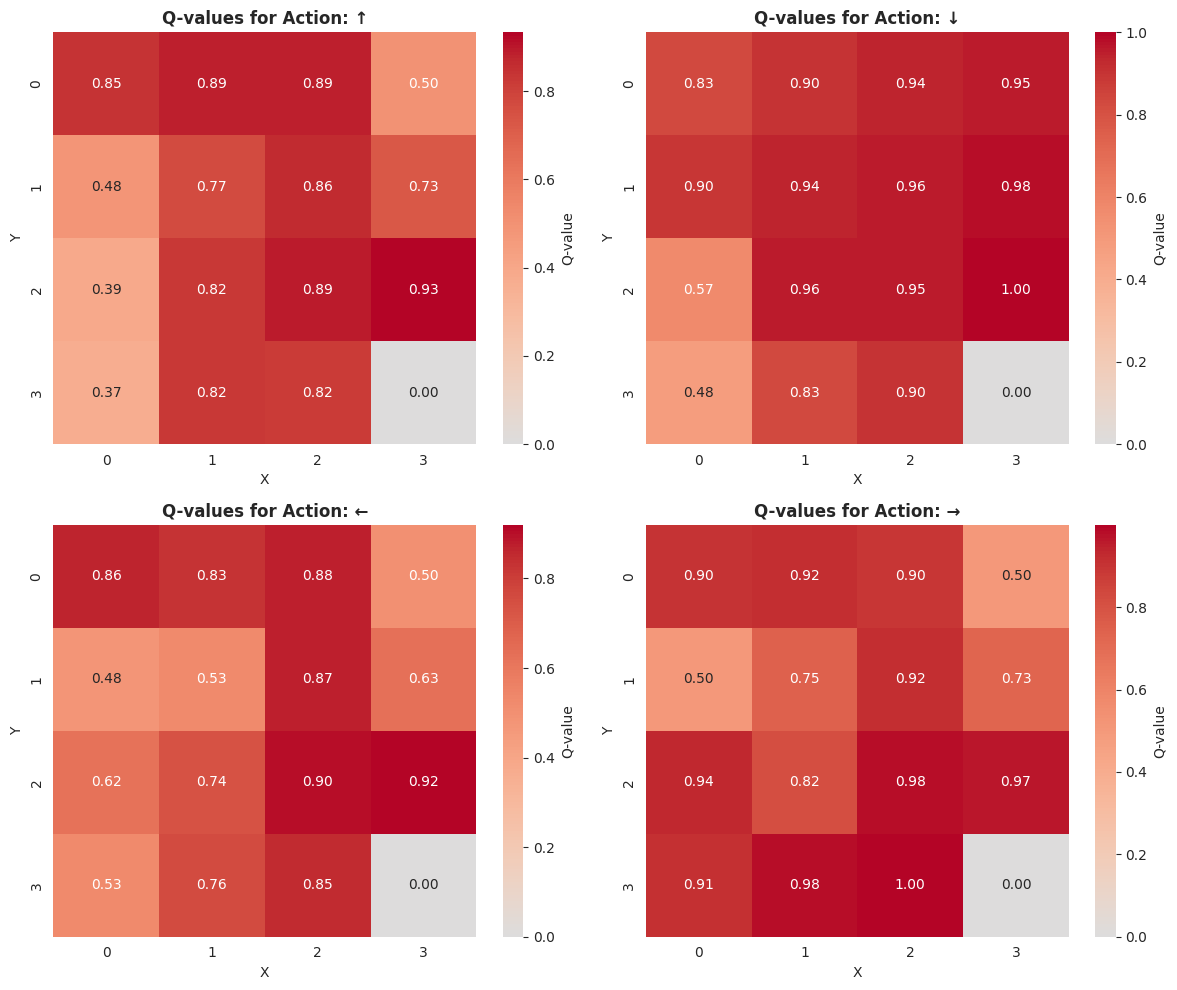

Notice how Q-values are highest for actions that move toward the goal!


In [19]:
# Create subplots for each action
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for action in range(env.n_actions):
    q_grid = np.zeros((env.size, env.size))
    
    for y in range(env.size):
        for x in range(env.size):
            state = (y, x)
            q_grid[y, x] = agent.q_table[(state, action)]
    
    sns.heatmap(q_grid, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, ax=axes[action], cbar_kws={'label': 'Q-value'})
    axes[action].set_title(f'Q-values for Action: {env.action_names[action]}', 
                          fontsize=12, fontweight='bold')
    axes[action].set_xlabel('X')
    axes[action].set_ylabel('Y')

plt.tight_layout()
plt.show()

print("Notice how Q-values are highest for actions that move toward the goal!")

## 11. Hyperparameter Impact

### 11.1 Learning Rate (α)

The learning rate controls how much we update Q-values each step.

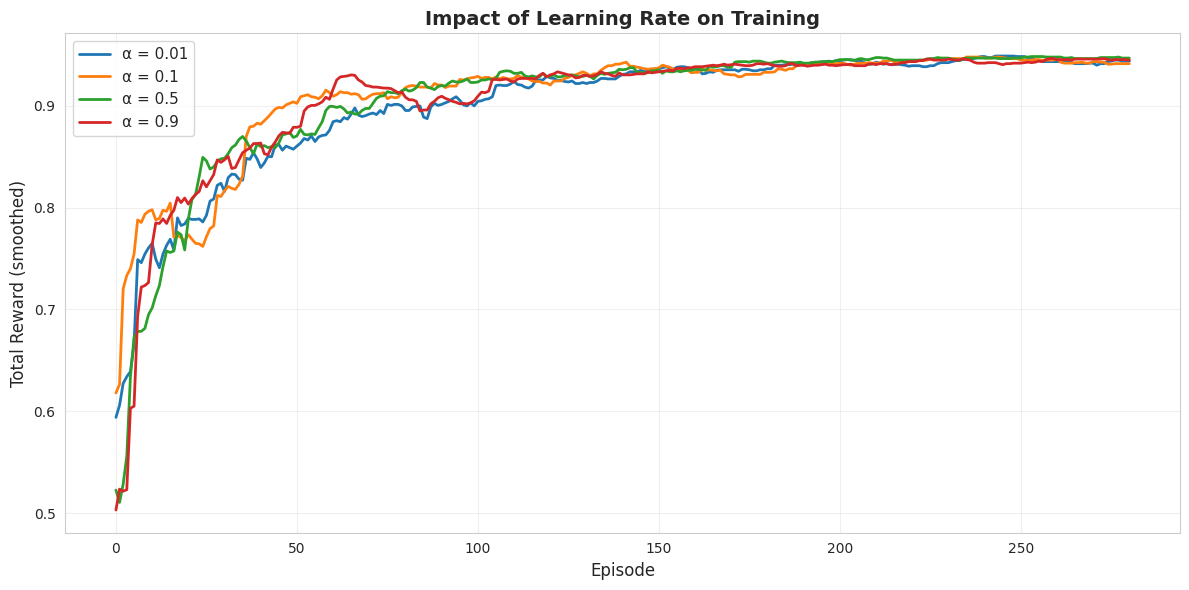

Too low (0.01): Learns slowly, may not converge in time
Too high (0.9): Unstable, overshoots optimal values
Just right (0.1-0.3): Smooth, stable convergence


In [20]:
# Compare different learning rates
learning_rates = [0.01, 0.1, 0.5, 0.9]
n_episodes = 300

plt.figure(figsize=(12, 6))

for lr in learning_rates:
    env = GridWorld(size=4)
    agent = QLearningAgent(n_actions=env.n_actions, learning_rate=lr, epsilon_decay=0.01)
    
    rewards = []
    for _ in range(n_episodes):
        reward, _ = agent.train_episode(env)
        rewards.append(reward)
    
    smoothed = moving_average(rewards, window=20)
    plt.plot(smoothed, label=f'α = {lr}', linewidth=2)

plt.xlabel('Episode', fontsize=12)
plt.ylabel('Total Reward (smoothed)', fontsize=12)
plt.title('Impact of Learning Rate on Training', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Too low (0.01): Learns slowly, may not converge in time")
print("Too high (0.9): Unstable, overshoots optimal values")
print("Just right (0.1-0.3): Smooth, stable convergence")

### 11.2 Discount Factor (γ)

The discount factor determines how much the agent values future rewards.

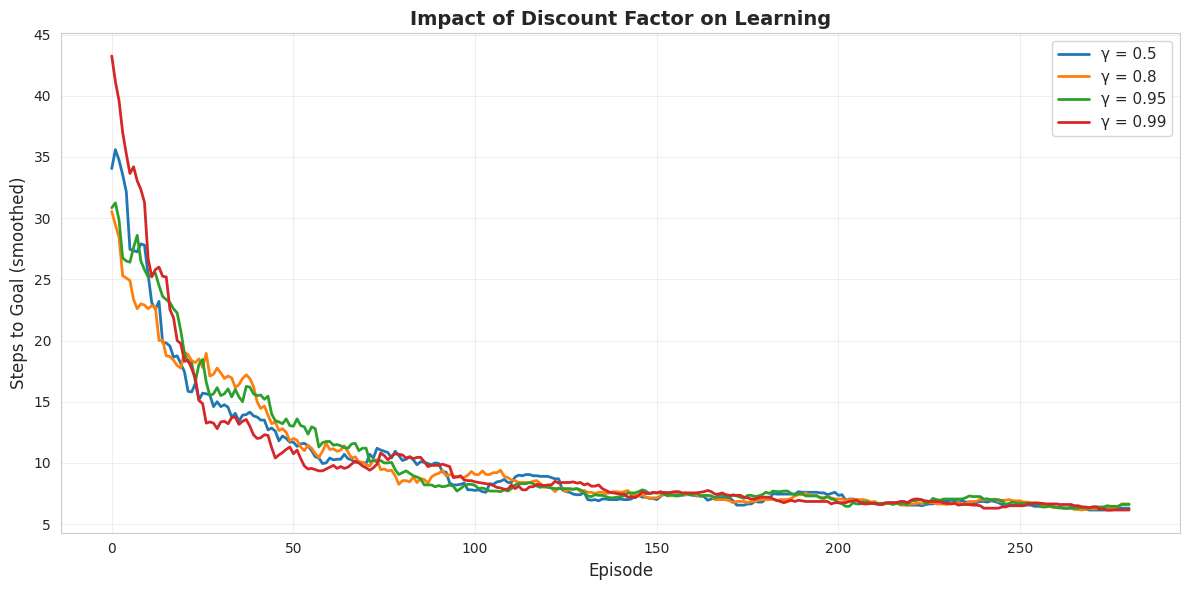

Low γ (0.5): Myopic, may take suboptimal paths
High γ (0.99): Far-sighted, learns optimal long-term strategy


In [21]:
# Compare different discount factors
gammas = [0.5, 0.8, 0.95, 0.99]
n_episodes = 300

plt.figure(figsize=(12, 6))

for gamma in gammas:
    env = GridWorld(size=4)
    agent = QLearningAgent(n_actions=env.n_actions, discount_factor=gamma, epsilon_decay=0.01)
    
    steps = []
    for _ in range(n_episodes):
        _, step_count = agent.train_episode(env)
        steps.append(step_count)
    
    smoothed = moving_average(steps, window=20)
    plt.plot(smoothed, label=f'γ = {gamma}', linewidth=2)

plt.xlabel('Episode', fontsize=12)
plt.ylabel('Steps to Goal (smoothed)', fontsize=12)
plt.title('Impact of Discount Factor on Learning', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Low γ (0.5): Myopic, may take suboptimal paths")
print("High γ (0.99): Far-sighted, learns optimal long-term strategy")

## 12. CartPole with Q-Learning

### 12.1 The CartPole Challenge

CartPole is a classic RL benchmark from OpenAI Gym:
- **State**: Cart position, cart velocity, pole angle, pole angular velocity (4 continuous values)
- **Actions**: Push cart left (0) or right (1)
- **Goal**: Keep pole balanced upright for as long as possible
- **Reward**: +1 for each timestep the pole stays up

**Problem**: States are **continuous**, but Q-learning needs discrete states!

**Solution**: **Discretization** - bin continuous values into discrete buckets.

### 12.2 State Discretization

We'll divide each continuous state dimension into bins.

In [22]:
class CartPoleDiscretizer:
    """Discretize continuous CartPole states into bins."""
    
    def __init__(self, n_bins: int = 10):
        self.n_bins = n_bins
        
        # Define bins for each state dimension
        # These ranges are from CartPole documentation
        self.bins = [
            np.linspace(-4.8, 4.8, n_bins),      # Cart position
            np.linspace(-4, 4, n_bins),          # Cart velocity
            np.linspace(-0.418, 0.418, n_bins),  # Pole angle (~24°)
            np.linspace(-4, 4, n_bins)           # Pole angular velocity
        ]
    
    def discretize(self, state: np.ndarray) -> tuple:
        """Convert continuous state to discrete state tuple."""
        discrete_state = []
        for i, value in enumerate(state):
            # Find which bin this value falls into
            bin_idx = np.digitize(value, self.bins[i]) - 1
            # Clip to valid range
            bin_idx = np.clip(bin_idx, 0, self.n_bins - 1)
            discrete_state.append(bin_idx)
        return tuple(discrete_state)

# Test discretization
discretizer = CartPoleDiscretizer(n_bins=10)

# Example continuous states
states = [
    np.array([0.0, 0.0, 0.0, 0.0]),      # Balanced at center
    np.array([2.0, 0.5, 0.1, -0.5]),     # Off-center, tilted
    np.array([-2.0, -1.0, -0.2, 1.0])    # Far left, tilted other way
]

print("Continuous → Discrete state mapping:\n")
for state in states:
    discrete = discretizer.discretize(state)
    print(f"Continuous: {state}")
    print(f"Discrete:   {discrete}\n")

Continuous → Discrete state mapping:

Continuous: [0. 0. 0. 0.]
Discrete:   (np.int64(4), np.int64(4), np.int64(4), np.int64(4))

Continuous: [ 2.   0.5  0.1 -0.5]
Discrete:   (np.int64(6), np.int64(5), np.int64(5), np.int64(3))

Continuous: [-2.  -1.  -0.2  1. ]
Discrete:   (np.int64(2), np.int64(3), np.int64(2), np.int64(5))



### 12.3 Training on CartPole

Now let's train a Q-learning agent on CartPole!

In [23]:
# Create CartPole environment
cartpole_env = gym.make('CartPole-v1')
discretizer = CartPoleDiscretizer(n_bins=10)

# Create agent
cartpole_agent = QLearningAgent(
    n_actions=cartpole_env.action_space.n,
    learning_rate=0.1,
    discount_factor=0.99,
    epsilon_start=1.0,
    epsilon_end=0.01,
    epsilon_decay=0.001
)

print(f"CartPole environment:")
print(f"  State space: {cartpole_env.observation_space}")
print(f"  Action space: {cartpole_env.action_space}")
print(f"  Discretized bins: {discretizer.n_bins} per dimension")
print(f"  Total discrete states: {discretizer.n_bins ** 4:,}")

CartPole environment:
  State space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
  Action space: Discrete(2)
  Discretized bins: 10 per dimension
  Total discrete states: 10,000


Execute the following code:

In [24]:
# Training loop for CartPole
n_episodes = 1000
cartpole_rewards = []

for episode in range(n_episodes):
    state, _ = cartpole_env.reset()
    state = discretizer.discretize(state)
    
    total_reward = 0
    done = False
    
    while not done:
        action = cartpole_agent.select_action(state, training=True)
        next_state, reward, terminated, truncated, _ = cartpole_env.step(action)
        done = terminated or truncated
        next_state = discretizer.discretize(next_state)
        
        cartpole_agent.update(state, action, reward, next_state, done)
        
        state = next_state
        total_reward += reward
    
    cartpole_rewards.append(total_reward)
    cartpole_agent.episode += 1
    
    if (episode + 1) % 200 == 0:
        avg_reward = np.mean(cartpole_rewards[-100:])
        epsilon = cartpole_agent.get_epsilon()
        print(f"Episode {episode + 1}: Avg Reward = {avg_reward:.1f}, ε = {epsilon:.3f}")

cartpole_env.close()
print("\nTraining complete!")

Episode 200: Avg Reward = 23.7, ε = 0.821


Episode 400: Avg Reward = 30.6, ε = 0.674


Episode 600: Avg Reward = 39.5, ε = 0.553


Episode 800: Avg Reward = 70.6, ε = 0.455


Episode 1000: Avg Reward = 77.7, ε = 0.374

Training complete!


### 12.4 CartPole Learning Curves

Let's visualize how the agent learned to balance the pole.

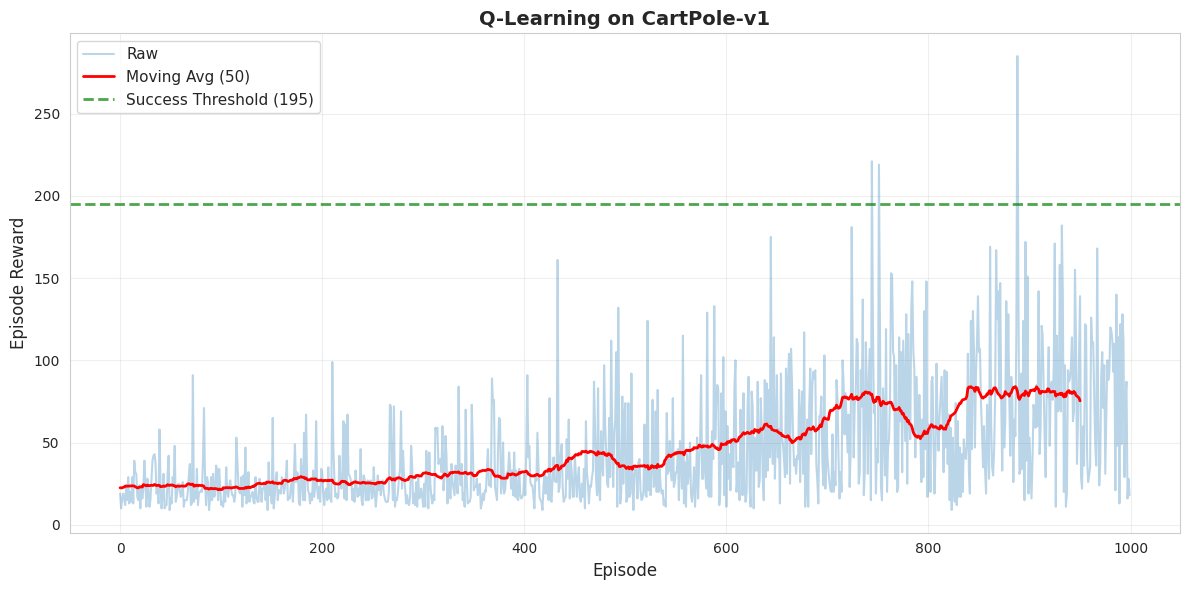


Final 100 episodes performance:
  Mean reward: 77.7
  Max reward: 182.0
  Success rate (≥195): 0%


In [25]:
# Plot CartPole learning curve
plt.figure(figsize=(12, 6))
plt.plot(cartpole_rewards, alpha=0.3, label='Raw')
plt.plot(moving_average(cartpole_rewards, window=50), linewidth=2, 
         color='red', label='Moving Avg (50)')
plt.axhline(195, color='green', linestyle='--', linewidth=2, 
            label='Success Threshold (195)', alpha=0.7)
plt.xlabel('Episode', fontsize=12)
plt.ylabel('Episode Reward', fontsize=12)
plt.title('Q-Learning on CartPole-v1', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Performance statistics
final_100 = cartpole_rewards[-100:]
print(f"\nFinal 100 episodes performance:")
print(f"  Mean reward: {np.mean(final_100):.1f}")
print(f"  Max reward: {np.max(final_100):.1f}")
print(f"  Success rate (≥195): {sum(r >= 195 for r in final_100)}%")

## 13. Limitations and Extensions

### 13.1 Limitations of Q-Learning

Q-learning works great for simple problems, but has limitations:

1. **Discrete states required**: Can't handle continuous states directly (need discretization)
2. **State space explosion**: Q-table grows exponentially with state dimensions
3. **No generalization**: Each state learned independently
4. **Memory intensive**: Must store Q-value for every state-action pair

For CartPole with 10 bins per dimension: $10^4 = 10,000$ states
For robotics with 20 dimensions: $10^{20}$ states - impossible!

### 13.2 Extensions and Modern RL

Q-learning inspired many powerful modern algorithms:

**Deep Q-Networks (DQN)**:
- Replace Q-table with neural network: $Q(s,a) \approx Q(s,a; \theta)$
- Network learns to generalize across similar states
- Can handle high-dimensional inputs (images!)

**Double Q-Learning**:
- Use two Q-functions to reduce overestimation bias
- More stable learning

**Prioritized Experience Replay**:
- Learn more from important transitions
- Sample experiences with higher TD error more frequently

**Rainbow DQN**:
- Combines 6+ improvements over vanilla DQN
- State-of-the-art performance on Atari games

All of these build on the fundamental Q-learning ideas you just learned!

## 14. Key Takeaways

### Core Concepts

1. **Reinforcement Learning Framework**:
   - Agent interacts with environment through state-action-reward loop
   - Goal: maximize cumulative discounted reward
   - No supervision - learns from trial and error

2. **Markov Decision Processes (MDPs)**:
   - Mathematical framework for sequential decision making
   - Markov property: future depends only on present state
   - Discount factor $\gamma$ balances immediate vs future rewards

3. **Q-Learning Algorithm**:
   - Learns action-value function Q(s,a)
   - Temporal difference update: $Q(s,a) \leftarrow Q(s,a) + \alpha[r + \gamma \max_{a'} Q(s',a') - Q(s,a)]$
   - Off-policy: learns optimal policy while exploring
   - Model-free: doesn't need environment dynamics

4. **Exploration vs Exploitation**:
   - ε-greedy balances trying new actions vs using learned policy
   - High ε early (explore) → Low ε later (exploit)
   - Essential for convergence to optimal policy

5. **Practical Considerations**:
   - Discretization enables Q-learning on continuous states
   - Learning rate, discount factor, epsilon decay are critical hyperparameters
   - State space size limits vanilla Q-learning (→ use deep RL)

### Why This Matters

Q-learning is the gateway to modern deep RL. The core ideas - value functions, temporal difference learning, exploration-exploitation trade-offs - appear in state-of-the-art algorithms like:
- DQN (DeepMind's Atari-playing agent)
- AlphaGo/AlphaZero (world-champion game AI)
- PPO/TRPO (robotics and continuous control)

Understanding Q-learning gives you the foundation to tackle cutting-edge RL research and applications!

### Next Steps

To deepen your RL knowledge:
1. Learn about **policy gradient methods** (REINFORCE, Actor-Critic)
2. Study **Deep Q-Networks (DQN)** for high-dimensional states
3. Explore **Monte Carlo Tree Search (MCTS)** for planning
4. Implement **multi-armed bandits** to understand exploration strategies
5. Apply RL to your own problems - games, robotics, optimization!